# Phase 3 - Supervised Models

Train and compare Logistic Regression, Random Forest and a Neural Network to
predict the `cluster_label` discovered in Phase 2. We then pick the best model
and save it (plus its scaler) for the Streamlit app.

In [1]:
import sys, os
# Make the src/ modules importable and run from the project root.
sys.path.append(os.path.abspath('../src'))
os.chdir(os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from preprocessing import FEATURE_COLUMNS, RANDOM_STATE, scale, split_data
import models as M
import evaluation as E

pd.set_option('display.width', 120)
print('Setup OK')

Setup OK


## 1. Load the labeled dataset and split

In [2]:
df = pd.read_csv('data/processed/wine_labeled.csv')

# Features = the 11 physicochemical + wine_type. Target = cluster_label.
feature_cols = FEATURE_COLUMNS + ['wine_type']
target_col = 'cluster_label'

# Encode the string labels to integers (0..k-1) for the models.
classes = sorted(df[target_col].unique())
label_to_int = {name: i for i, name in enumerate(classes)}
int_to_label = {i: name for name, i in label_to_int.items()}
df['target_int'] = df[target_col].map(label_to_int)

train_df, val_df, test_df = split_data(df, target_column='target_int')
print('train/val/test sizes:', len(train_df), len(val_df), len(test_df))
print('classes:', classes)

train/val/test sizes: 3724 798 798
classes: ['bold structured reds', 'dry high-alcohol wines', 'light acidic reds', 'sweet low-alcohol whites']


## 2. Scale the features

We fit the scaler on the training set only and save it for the app.

In [3]:
# scale() fits on train and only transforms val/test (no leakage).
# It scales FEATURE_COLUMNS (the 11). wine_type is already 0/1, left as-is.
train_s, val_s, test_s = scale(train_df, [val_df, test_df])

X_train = train_s[feature_cols].values
X_val   = val_s[feature_cols].values
X_test  = test_s[feature_cols].values

y_train = train_s['target_int'].values
y_val   = val_s['target_int'].values
y_test  = test_s['target_int'].values

print('X_train shape:', X_train.shape)

X_train shape: (3724, 12)


## 3. Train the three models

In [4]:
import time

# Model 1: Logistic Regression (baseline)
t0 = time.perf_counter()
logreg = M.train_logistic_regression(X_train, y_train)
t_logreg = time.perf_counter() - t0

# Model 2: Random Forest
t0 = time.perf_counter()
rf = M.train_random_forest(X_train, y_train)
t_rf = time.perf_counter() - t0

print(f'LogReg trained in {t_logreg:.2f}s | RF trained in {t_rf:.2f}s')

C:\Users\ssancheze\Desktop\Univalle\Ing\IA\project_2\wine-quality-ml\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogReg trained in 0.04s | RF trained in 1.00s


In [5]:
# Model 3: Neural Network (mandatory). Uses the validation set for EarlyStopping.
n_classes = len(classes)
input_dim = X_train.shape[1]

t0 = time.perf_counter()
nn, history = M.train_neural_network(
    X_train, y_train, X_val, y_val,
    input_dim=input_dim, n_classes=n_classes,
    epochs=100, batch_size=32,
)
t_nn = time.perf_counter() - t0
print(f'NN trained in {t_nn:.2f}s, stopped at epoch {len(history.history["loss"])}')

Epoch 1/100


  1/117 ━━━━━━━━━━━━━━━━━━━━ 5:43 3s/step - accuracy: 0.2812 - loss: 1.7889

 21/117 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3825 - loss: 1.5069 

 44/117 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.4605 - loss: 1.3320

 67/117 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5195 - loss: 1.1977

...

 72/117 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9674 - loss: 0.0939

 89/117 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9664 - loss: 0.0965

107/117 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9656 - loss: 0.0987

117/117 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9621 - loss: 0.1088 - val_accuracy: 0.9787 - val_loss: 0.0564 - learning_rate: 5.0000e-04


NN trained in 25.56s, stopped at epoch 23


## 4. Learning curves of the neural network

Train vs validation loss/accuracy: if val loss starts rising while train keeps
falling, that is overfitting. EarlyStopping is what prevents it.

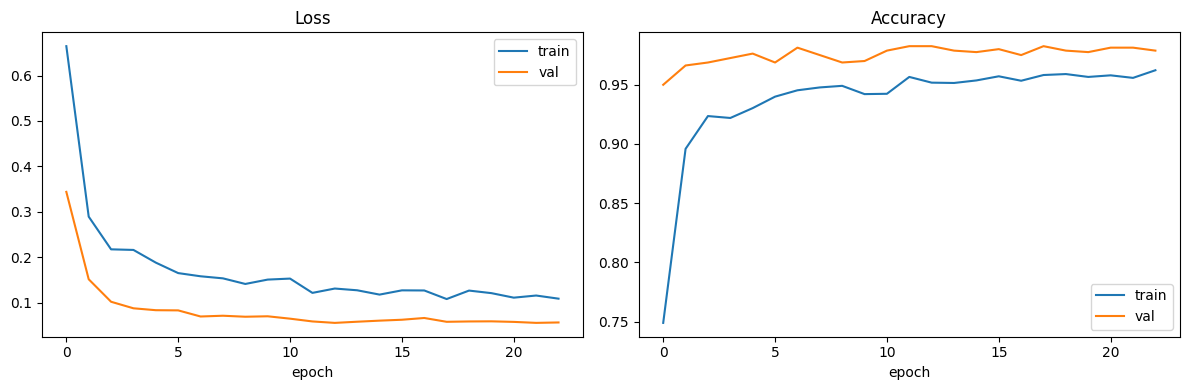

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(history.history['loss'], label='train')
ax1.plot(history.history['val_loss'], label='val')
ax1.set_title('Loss'); ax1.set_xlabel('epoch'); ax1.legend()
ax2.plot(history.history['accuracy'], label='train')
ax2.plot(history.history['val_accuracy'], label='val')
ax2.set_title('Accuracy'); ax2.set_xlabel('epoch'); ax2.legend()
plt.tight_layout()
plt.savefig('reports/figures/nn_learning_curves.png', dpi=120)
plt.show()

## 5. Evaluate all models on the test set

In [7]:
res_logreg = E.evaluate_model(logreg, X_test, y_test, is_keras=False, model_name='Logistic Regression')
res_rf     = E.evaluate_model(rf,     X_test, y_test, is_keras=False, model_name='Random Forest')
res_nn     = E.evaluate_model(nn,     X_test, y_test, is_keras=True,  model_name='Neural Network')

# Attach train and inference times.
res_logreg['train_time'] = t_logreg
res_rf['train_time'] = t_rf
res_nn['train_time'] = t_nn
res_logreg['inference_time'] = E.measure_inference_time(logreg, X_test, False)
res_rf['inference_time'] = E.measure_inference_time(rf, X_test, False)
res_nn['inference_time'] = E.measure_inference_time(nn, X_test, True)

comparison = E.build_comparison_table([res_logreg, res_rf, res_nn])
comparison

,model,accuracy,precision_macro,recall_macro,f1_macro,roc_auc_ovr,train_time,inference_time
0,Logistic Regression,0.994987,0.991327,0.995164,0.993229,0.999983,0.043777,0.000258
1,Neural Network,0.983709,0.982740,0.977323,0.979993,0.999736,25.558369,0.176693
2,Random Forest,0.964912,0.963401,0.954063,0.958594,0.998664,0.997854,0.096830


## 6. Confusion matrix of the best model

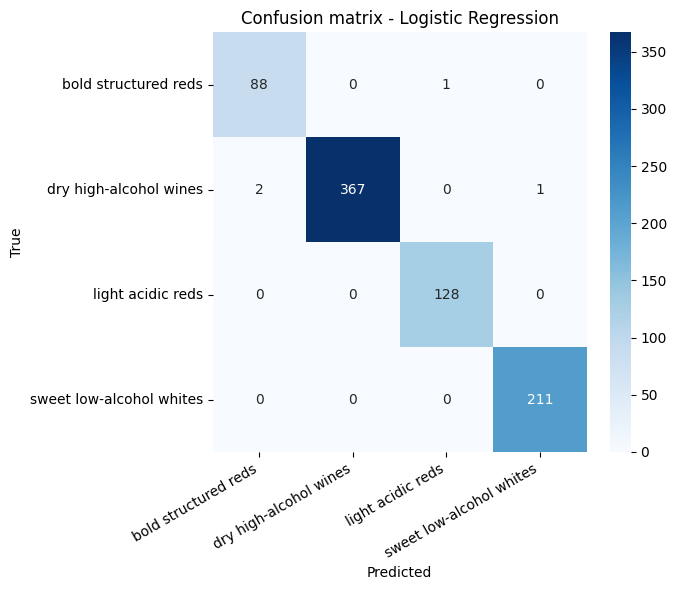

              precision    recall  f1-score   support

           0       0.98      0.99      0.98        89
           1       1.00      0.99      1.00       370
           2       0.99      1.00      1.00       128
           3       1.00      1.00      1.00       211

    accuracy                           0.99       798
   macro avg       0.99      1.00      0.99       798
weighted avg       1.00      0.99      0.99       798



In [8]:
best_name = comparison.iloc[0]['model']
best_model = {'Logistic Regression': logreg, 'Random Forest': rf, 'Neural Network': nn}[best_name]
is_keras_best = best_name == 'Neural Network'

cm = E.get_confusion_matrix(best_model, X_test, y_test, is_keras=is_keras_best)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title(f'Confusion matrix - {best_name}')
plt.ylabel('True'); plt.xlabel('Predicted')
plt.xticks(rotation=30, ha='right'); plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('reports/figures/confusion_matrix.png', dpi=120)
plt.show()

print(E.get_classification_report(best_model, X_test, y_test, is_keras=is_keras_best))

## 7. Save the final model + scaler for the app

In [9]:
# Always save the sklearn models; save the NN in Keras format too.
M.save_sklearn_model(rf, 'models/rf_model.pkl')
M.save_sklearn_model(logreg, 'models/logreg_model.pkl')
M.save_keras_model(nn, 'models/nn_model.h5')

print('Best model:', best_name)
print('Artifacts saved in models/. The app loads models/rf_model.pkl by default;')
print('if the NN is best, point app.py to models/nn_model.h5 instead.')

Best model: Logistic Regression
Artifacts saved in models/. The app loads models/rf_model.pkl by default;
if the NN is best, point app.py to models/nn_model.h5 instead.
